# Analyse factorielle des correspondances


Les données ont été produites avec le carnet [Production aléatoire d'observations](production_aleatoire_observations_llm.ipynb)


Il s'agit de données synthétiques sans aucune relation avec la réalité et dont la finalité est uniquement l'apprentissages de méthodes d'analyse. 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as stats
import sqlite3 as sql

In [2]:
from fanalysis.ca import CA 
from fanalysis.mca import MCA

In [3]:
### Lire le fichier corrigé manuellement – ne pas effacer !

path =  'data/llama3_20250315.csv'

obs = pd.read_csv(path)
obs.set_index('id', inplace=True)
obs.head()

,age,gender,monthly_revenue,newspaper_reading_frequency,political_orientation,time_social_media
id,,,,,,
1,39,Other,18539,daily,Rightwing,54
2,81,Male,4261,week-end,Populist,1
3,60,Male,41083,daily,Rightwing,123
4,51,Female,10255,3-4 days a week,Center,144
5,30,Male,44891,daily,Rightwing,105


In [4]:
### Créer une copie indépendante du DataFrame (attention aux copies de variables qui sont seulement des alias) 
# et coder les années de naissance en relation avec un découpage significatif au point de vue heuristique, et modifiable si besion
## fonction pd.cut : https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.cut.html

generations = [18, 26, 36, 46, 56, 66, 91]
c_obs = obs.copy(deep=True)
c_obs['generation'] = pd.cut(c_obs['age'], generations, right=False)
c_obs['generation'] = c_obs['generation'].apply(lambda x : str(int(x.left))+'-'+ str(int(x.right)-1))\
       .astype(dtype='str')
# Inspection
c_obs.head()

,age,gender,monthly_revenue,newspaper_reading_frequency,political_orientation,time_social_media,generation
id,,,,,,,
1,39,Other,18539,daily,Rightwing,54,36-45
2,81,Male,4261,week-end,Populist,1,66-90
3,60,Male,41083,daily,Rightwing,123,56-65
4,51,Female,10255,3-4 days a week,Center,144,46-55
5,30,Male,44891,daily,Rightwing,105,26-35


In [5]:
## fonction pd.cut : https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.cut.html

classes_revenu = [0,3000, 4500, 6000, 8000, 10000, 12000, 300000]
c_obs['classe_revenu'] = pd.cut(c_obs['monthly_revenue'], classes_revenu, right=False)
c_obs.head()

,age,gender,monthly_revenue,newspaper_reading_frequency,political_orientation,time_social_media,generation,classe_revenu
id,,,,,,,,
1,39,Other,18539,daily,Rightwing,54,36-45,"[12000, 300000)"
2,81,Male,4261,week-end,Populist,1,66-90,"[3000, 4500)"
3,60,Male,41083,daily,Rightwing,123,56-65,"[12000, 300000)"
4,51,Female,10255,3-4 days a week,Center,144,46-55,"[10000, 12000)"
5,30,Male,44891,daily,Rightwing,105,26-35,"[12000, 300000)"


In [6]:

c_obs['classe_revenu'] = c_obs['classe_revenu']\
    .apply(lambda x : str(int(x.left))+'-'+ str(int(x.right)-1)).astype(dtype='str')

# Inspection
c_obs.head()

,age,gender,monthly_revenue,newspaper_reading_frequency,political_orientation,time_social_media,generation,classe_revenu
id,,,,,,,,
1,39,Other,18539,daily,Rightwing,54,36-45,12000-299999
2,81,Male,4261,week-end,Populist,1,66-90,3000-4499
3,60,Male,41083,daily,Rightwing,123,56-65,12000-299999
4,51,Female,10255,3-4 days a week,Center,144,46-55,10000-11999
5,30,Male,44891,daily,Rightwing,105,26-35,12000-299999


In [7]:
### Classe consommation de médias
# fonction pd.qcut : https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.qcut.html

c_obs['classe_media'] = pd.qcut(c_obs['time_social_media'], 10)
c_obs['classe_media'] = c_obs['classe_media'].apply(lambda x : str(int(x.left))+'-'+ str(int(x.right)-1))\
       .astype(dtype='str')
c_obs.head()

,age,gender,monthly_revenue,newspaper_reading_frequency,political_orientation,time_social_media,generation,classe_revenu,classe_media
id,,,,,,,,,
1,39,Other,18539,daily,Rightwing,54,36-45,12000-299999,37-91
2,81,Male,4261,week-end,Populist,1,66-90,3000-4499,0-4
3,60,Male,41083,daily,Rightwing,123,56-65,12000-299999,114-122
4,51,Female,10255,3-4 days a week,Center,144,46-55,10000-11999,133-145
5,30,Male,44891,daily,Rightwing,105,26-35,12000-299999,92-104


## Age et orientation politique

### Tableau de contingence

In [8]:
### La fonction pivot_table produit un tableau de contingence
## Au centre du tableau se trouvent les effectifs conjoints, 
## aux bords les effectifs marginaux qui correspondent 
## aux distributions indépendantes des variables

X = "political_orientation"  # "0"
Y = "generation"

ddf = c_obs[[Y,X]].pivot_table(index=Y,columns=X,aggfunc=len,margins=True,margins_name="Total").fillna(0).astype(int)
ddf

political_orientation,Center,Ecologist,Leftwing,Populist,Rightwing,Total
generation,,,,,,
18-25,0,46,20,32,22,120
26-35,35,86,114,73,62,370
36-45,54,54,139,62,61,370
46-55,50,38,112,32,39,271
56-65,57,19,75,50,39,240
66-90,100,0,64,85,80,329
Total,296,243,524,334,303,1700


In [9]:
D = ddf.iloc[:-1,:-1].copy(deep=True)
D

political_orientation,Center,Ecologist,Leftwing,Populist,Rightwing
generation,,,,,
18-25,0,46,20,32,22
26-35,35,86,114,73,62
36-45,54,54,139,62,61
46-55,50,38,112,32,39
56-65,57,19,75,50,39
66-90,100,0,64,85,80


In [10]:
## Nombre de modalités ligne
K = D.shape[0]
## Nombre de modalités colonnes
L = D.shape[1]
# Effectif total
n = np.sum(D.values)
# Nombre max. de facteur
Hmax = np.min([K-1,L-1])

print('Dimensions: (', K, ',', L, '), effectif:', n, ', nombre max. facteurs:', Hmax)

Dimensions: ( 6 , 5 ), effectif: 1700 , nombre max. facteurs: 4


In [11]:
### Valeurs produites par la fonction de la librairie 'stats'
statistic, p, dof, expected = stats.chi2_contingency(D)

print('Chi2 :', statistic, ', dof :',dof)
print('p-value :', p)


print('phi2 = inertie (variance totale) :', statistic/n)


### Tableau à l'indépendance
dfe = round(pd.DataFrame(expected),4)

### Coéfficient de Cramer
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.contingency.association.html

vc = stats.contingency.association(D.iloc[:-1,:-1], method='cramer')
print('Cramer: ', vc)

Chi2 : 263.668259158452 , dof : 20
p-value : 1.9774563334793587e-44
phi2 = inertie (variance totale) : 0.15509897597556
Cramer:  0.19096104113222523


### Commentaire

Noter la petite valeur de p value, on peut rejeter l'hypothèse d'indépendance. 

Le lien n'est pas très fort, mais on profite des axes factoriels pour prendre connaissance des tendances 

In [12]:
afc = CA(row_labels=D.index,col_labels=D.columns)
afc.fit(D.values)

CA(col_labels=Index(['Center', 'Ecologist', 'Leftwing', 'Populist', 'Rightwing'], dtype='object', name='political_orientation'),
   row_labels=Index(['18-25', '26-35', '36-45', '46-55', '56-65', '66-90'], dtype='object', name='generation'))

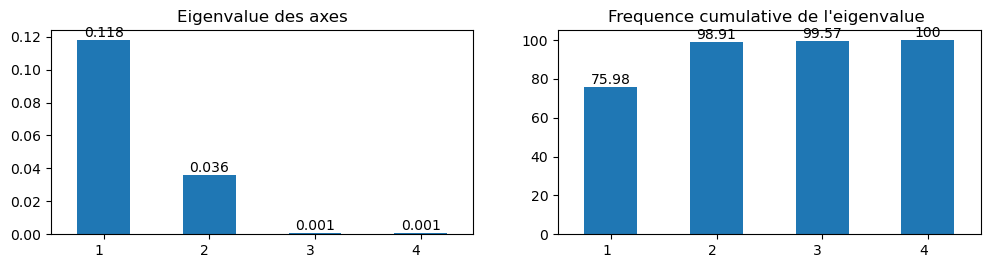

In [13]:
eig = pd.DataFrame(afc.eig_)

r1 = round(eig.iloc[0], 3)
r2 = round(eig.iloc[2], 2)
s=list(range(1,len(r1)+1))
r1.index=s
r2.index=s

# https://www.statology.org/pandas-subplots/
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,3))

ax1 = r1.plot(kind='bar', ax=axes[0], title='Eigenvalue des axes')
ax2 = r2.plot(kind='bar', ax=axes[1], title="Frequence cumulative de l'eigenvalue ")


ax1.bar_label(ax1.containers[0])
ax2.bar_label(ax2.containers[0])


# Met les valeurs xticks en vertical
fig.autofmt_xdate(rotation=0)
plt.show()

NB: la valeur propre des axes (eigenvalue) est la valeur de la variance exprimée par ce axe. Il s'agit donc d'une portion du phi-2, i.e. du chi-2 divisé par le nombre d'individus de la population. 100% de la variance équivaut au phi-2.
<br/>

### Distances des lignes / des colonnes

In [14]:
# Calcul des profils des lignes
prof_lig = np.apply_along_axis(arr=D.values,axis=1,
                               func1d=lambda x:x/np.sum(x))
# Calul du profil marginal correspondant
# Cf. ligne grisée de Figure 100, Rakotomalala, 2020
tot_col = ddf.loc['Total'][:5]
prof_marg_lig = tot_col/np.sum(tot_col)

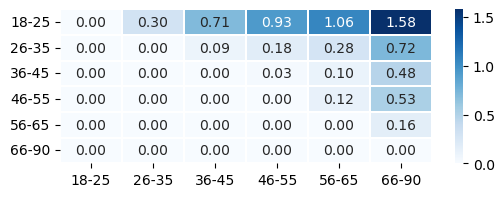

In [15]:
### Distance entre paires de modalités lignes,
# calculée sur la base des valeurs dans la note précédente

fig, ax = plt.subplots(figsize=(6,2))

distPairesLig = np.zeros(shape=(prof_lig.shape[0],prof_lig.shape[0]))
#double boucle
for i in range(prof_lig.shape[0]):
    for j in range(i+1,prof_lig.shape[0]):
        distPairesLig[i,j] = np.sum((prof_lig[i,:]-prof_lig[j,:])**2/prof_marg_lig)

sns.heatmap(distPairesLig,vmin=0,vmax=np.max(distPairesLig),linewidth=0.1,cmap=
'Blues',xticklabels=D.index,yticklabels=D.index,
fmt=".2f", annot=True)


### ATTENTION: plus la couleur est foncée, plus la distance est grande
plt.show()

In [16]:
# Profil marginal des colonnes
tot_lig = np.sum(D.values,axis=1)
prof_marg_col = tot_lig/np.sum(tot_lig)

# Tableau des profils colonnes
prof_col = np.apply_along_axis(arr=D.values,axis=0,
                               func1d=lambda x:x/np.sum(x))
#print(pd.DataFrame(prof_col,index=D.index,columns=D.columns))
### Transposer pour garder la structure du code Python des lignes 
t_prof_col = prof_col.T

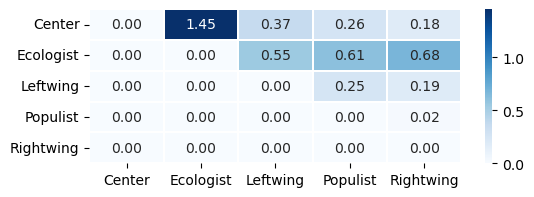

In [17]:
### Distance entre paires de modalités colonnes,
# calculée sur la base des valeurs précédentes  

fig, ax = plt.subplots(figsize=(6,2))


distPairesCol = np.zeros(shape=(t_prof_col.shape[0],
                                t_prof_col.shape[0]))
#double boucle
for i in range(t_prof_col.shape[0]-1):
    for j in range(i+1,t_prof_col.shape[0]):        
        distPairesCol[i,j] = np.sum((t_prof_col[i,:]-t_prof_col[j,:])**2/prof_marg_col)
#distPairesLig[j,i] = distPairesLig[i,j]
#affichage
#print(pd.DataFrame(distPairesLig,index=D.index,columns=D.index))

sns.heatmap(distPairesCol,vmin=0,vmax=np.max(distPairesCol),
            linewidth=0.1,cmap='Blues',xticklabels=D.columns,
            yticklabels=D.columns, 
fmt=".2f", annot=True)

plt.show()

### Graphiques et interprétation du premier plan factoriel

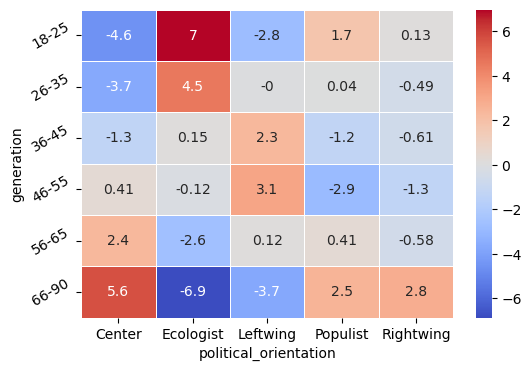

In [18]:
### Résidus pondérés (avec le signe)
### Doc. :
#   Rakotomalala, p.240
residus_ponderes = (round((D.values-dfe)/np.sqrt(dfe),2))
residus_ponderes.columns= D.columns
residus_ponderes.index=D.index


fig, ax = plt.subplots(figsize=(6,4))         
# Sample figsize in inches
g = sns.heatmap(residus_ponderes, annot=residus_ponderes, cmap="coolwarm", linewidths=.5, ax=ax)
labels = residus_ponderes.index
p = g.set_yticklabels(labels, rotation=30)

plt.show()


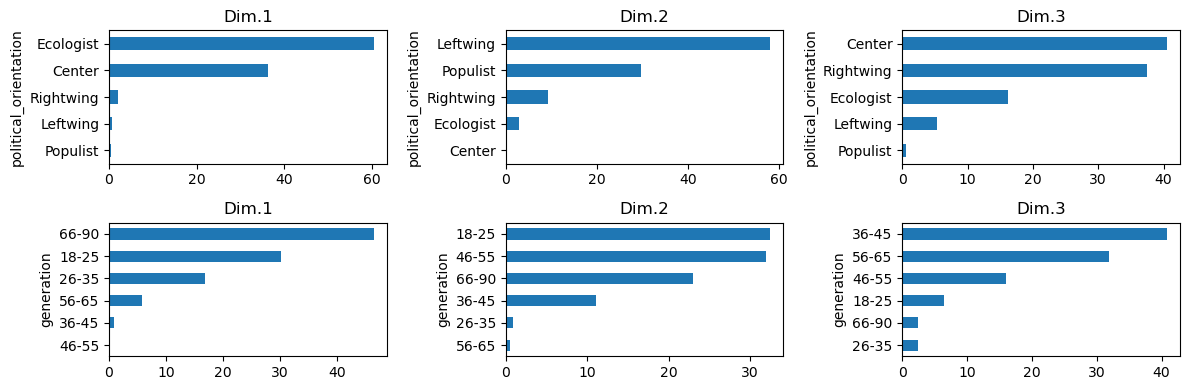

In [19]:
# Informations sur les contributions des colonnes
df = afc.col_topandas()[['col_contrib_dim1',
                         'col_contrib_dim2',
                         'col_contrib_dim3']]

r1 = df.iloc[:,0]
r2 = df.iloc[:,1]
r3 = df.iloc[:,2]

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12,4))

r1.sort_values().plot(kind='barh', ax=axes[0,0], title='Dim.1')
r2.sort_values().plot(kind='barh', ax=axes[0,1], title='Dim.2')
r3.sort_values().plot(kind='barh', ax=axes[0,2], title='Dim.3')

### Rows
df = afc.row_topandas()[['row_contrib_dim1',
                         'row_contrib_dim2',
                         'row_contrib_dim3']]
r1 = df.iloc[:,0]
r2 = df.iloc[:,1]
r3 = df.iloc[:,2]

r1.sort_values().plot(kind='barh', ax=axes[1,0], title='Dim.1')
r2.sort_values().plot(kind='barh', ax=axes[1,1], title='Dim.2')
r3.sort_values().plot(kind='barh', ax=axes[1,2], title='Dim.3')

plt.tight_layout()
plt.show()


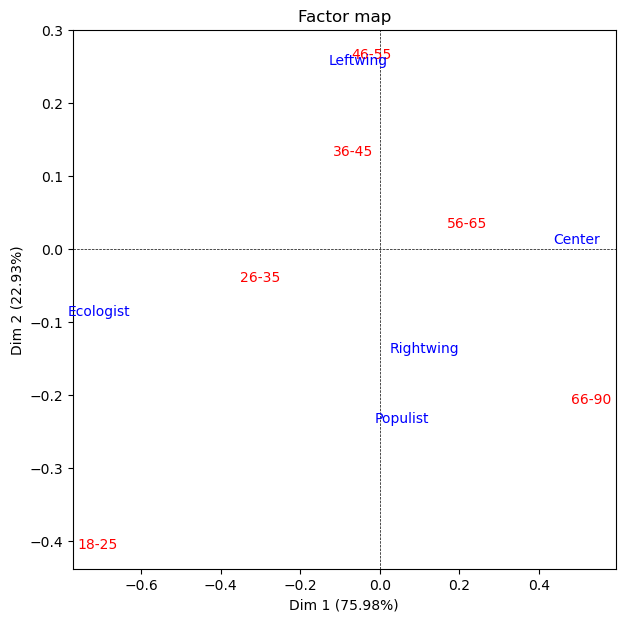

In [20]:
# Représentation simultanée, avec amplification
afc.mapping(num_x_axis=1,num_y_axis=2,figsize=(7,7))

### Représenter l'autre plan factoriel

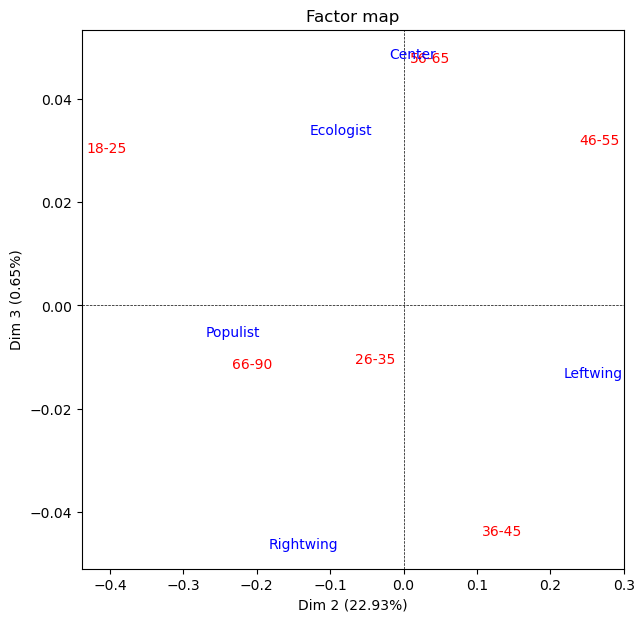

In [21]:
# Représentation simultanée, avec amplification
afc.mapping(num_x_axis=2,num_y_axis=3,figsize=(7,7))

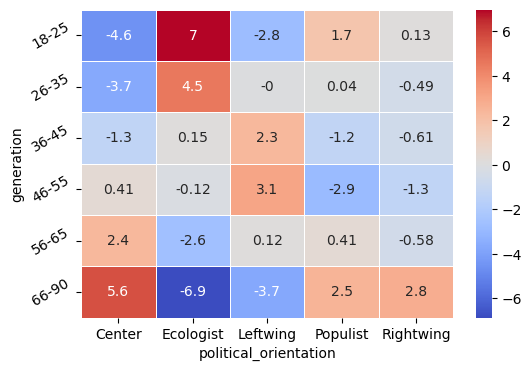

In [22]:
### Résidus pondérés (avec le signe)
### Doc. :
#   Rakotomalala, p.240
residus_ponderes = (round((D.values-dfe)/np.sqrt(dfe),2))
residus_ponderes.columns= D.columns
residus_ponderes.index=D.index


fig, ax = plt.subplots(figsize=(6,4))         
# Sample figsize in inches
g = sns.heatmap(residus_ponderes, annot=residus_ponderes, cmap="coolwarm", linewidths=.5, ax=ax)
labels = residus_ponderes.index
p = g.set_yticklabels(labels, rotation=30)

plt.show()


---------

## Genre et orientation politique

In [23]:
X = "gender"
Y = "political_orientation"  # "0"

ddf = c_obs[[Y,X]].pivot_table(index=X,columns=Y,aggfunc=len,margins=True,margins_name="Total").fillna(0).astype(int) 
ddf

political_orientation,Center,Ecologist,Leftwing,Populist,Rightwing,Total
gender,,,,,,
Female,142,120,259,162,158,841
Male,141,110,233,154,131,769
Other,13,13,32,18,14,90
Total,296,243,524,334,303,1700


In [24]:
D = ddf.iloc[:-1,:-1].copy(deep=True)
D

political_orientation,Center,Ecologist,Leftwing,Populist,Rightwing
gender,,,,,
Female,142,120,259,162,158
Male,141,110,233,154,131
Other,13,13,32,18,14


In [25]:
## Nombre de modalités ligne, 
# variable: catégories socio-professionnelles des parents
K = D.shape[0]
## Nombre de modalités colonnes,
# variable : filière d'études chosie
L = D.shape[1]
# Effectif total
n = np.sum(D.values)
# Nombre max. de facteur
Hmax = np.min([K-1,L-1])

print('Dimensions: (', K, ',', L, '), effectif:', n, ', nombre max. facteurs:', Hmax)

Dimensions: ( 3 , 5 ), effectif: 1700 , nombre max. facteurs: 2


In [26]:
### Valeurs produites par une fonction
statistic, p, dof, expected = stats.chi2_contingency(D)

print('Chi2 :', statistic, ', dof :',dof)
print('p-value :', p)


print('phi2 = inertie (variance totale) :', statistic/n)


### Tableau à l'indépendance
dfe = round(pd.DataFrame(expected),4)

### Coéfficient de Cramer
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.contingency.association.html

vc = stats.contingency.association(D, method='cramer')
print('Cramer: ', vc)

Chi2 : 2.7818626235261616 , dof : 8
p-value : 0.9472921861461464
phi2 = inertie (variance totale) : 0.001636389778544801
Cramer:  0.028604106161046187


In [27]:
afc = CA(row_labels=D.index,col_labels=D.columns)
afc.fit(D.values)

CA(col_labels=Index(['Center', 'Ecologist', 'Leftwing', 'Populist', 'Rightwing'], dtype='object', name='political_orientation'),
   row_labels=Index(['Female', 'Male', 'Other'], dtype='object', name='gender'))

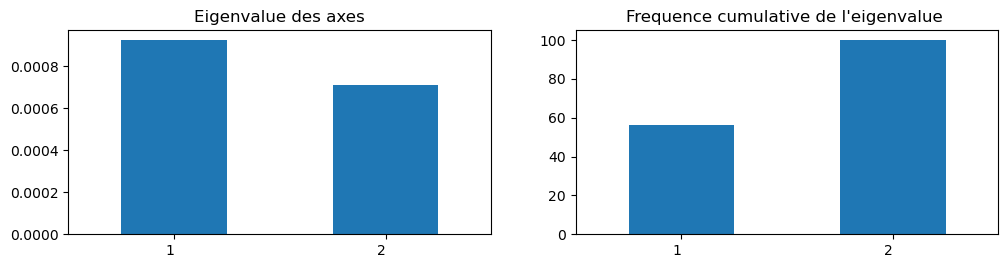

In [28]:
eig = pd.DataFrame(afc.eig_)

r1 = eig.iloc[0]
r2 = eig.iloc[2]
s=list(range(1,len(r1)+1))
r1.index=s
r2.index=s

# https://www.statology.org/pandas-subplots/
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,3))

r1.plot(kind='bar', ax=axes[0], title='Eigenvalue des axes')
r2.plot(kind='bar', ax=axes[1], title="Frequence cumulative de l'eigenvalue ")
# Met les valeurs xticks en vertical
fig.autofmt_xdate(rotation=0)
plt.show()

### Commentaire

Pas la peine de poursuivre, seulement deux modalités pour la variable genre, et un seul axe factoriel. 

Une analyse bivariée avec test du chi-2 suffit.

--------

## Orientation politique et fréquence de lecture du journal

In [29]:
c_obs.head(2)

,age,gender,monthly_revenue,newspaper_reading_frequency,political_orientation,time_social_media,generation,classe_revenu,classe_media
id,,,,,,,,,
1,39,Other,18539,daily,Rightwing,54,36-45,12000-299999,37-91
2,81,Male,4261,week-end,Populist,1,66-90,3000-4499,0-4


In [30]:
X = "political_orientation"  # "0"
Y = "newspaper_reading_frequency"

ddf = c_obs[[Y,X]].pivot_table(index=X,columns=Y,aggfunc=len,margins=True,margins_name="Total").fillna(0).astype(int) 
ddf

newspaper_reading_frequency,3-4 days a week,daily,rarely,sometimes,week-end,Total
political_orientation,,,,,,
Center,153,91,0,2,50,296
Ecologist,19,0,66,90,68,243
Leftwing,152,132,23,87,130,524
Populist,39,0,51,109,135,334
Rightwing,152,150,0,0,1,303
Total,515,373,140,288,384,1700


In [31]:
ddf = ddf[['rarely', 'rarely', 'week-end', '3-4 days a week', 'daily','Total']]
ddf.columns = ['0 très rar', '1 de temps', '2 week-end', '3 trois-quatre', '4 tous les','Total']
ddf

,0 très rar,1 de temps,2 week-end,3 trois-quatre,4 tous les,Total
political_orientation,,,,,,
Center,0,0,50,153,91,296
Ecologist,66,66,68,19,0,243
Leftwing,23,23,130,152,132,524
Populist,51,51,135,39,0,334
Rightwing,0,0,1,152,150,303
Total,140,140,384,515,373,1700


In [32]:
D = ddf.iloc[:-1,:-1].copy(deep=True)
D

,0 très rar,1 de temps,2 week-end,3 trois-quatre,4 tous les
political_orientation,,,,,
Center,0,0,50,153,91
Ecologist,66,66,68,19,0
Leftwing,23,23,130,152,132
Populist,51,51,135,39,0
Rightwing,0,0,1,152,150


In [33]:
## Nombre de modalités ligne, 
# variable: catégories socio-professionnelles des parents
K = D.shape[0]
## Nombre de modalités colonnes,
# variable : filière d'études chosie
L = D.shape[1]
# Effectif total
n = np.sum(D.values)
# Nombre max. de facteur
Hmax = np.min([K-1,L-1])

print('Dimensions: (', K, ',', L, '), effectif:', n, ', nombre max. facteurs:', Hmax)

Dimensions: ( 5 , 5 ), effectif: 1552 , nombre max. facteurs: 4


In [34]:
### Valeurs produites par une fonction
statistic, p, dof, expected = stats.chi2_contingency(D)

print('Chi2 :', statistic, ', dof :',dof)
print('p-value :', p)


print('phi2 = inertie (variance totale) :', statistic/n)


### Tableau à l'indépendance
dfe = round(pd.DataFrame(expected),4)

### Coéfficient de Cramer
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.contingency.association.html

vc = stats.contingency.association(D.iloc[:-1,:-1], method='cramer')
print('Cramer: ', vc)

Chi2 : 884.97704057798 , dof : 16
p-value : 4.5234541683400607e-178
phi2 = inertie (variance totale) : 0.5702171653208634
Cramer:  0.34998994774117576


In [35]:
afc = CA(row_labels=D.index,col_labels=D.columns)
afc.fit(D.values)

CA(col_labels=Index(['0 très rar', '1 de temps', '2 week-end', '3 trois-quatre',
       '4 tous les'],
      dtype='object'),
   row_labels=Index(['Center', 'Ecologist', 'Leftwing', 'Populist', 'Rightwing'], dtype='object', name='political_orientation'))

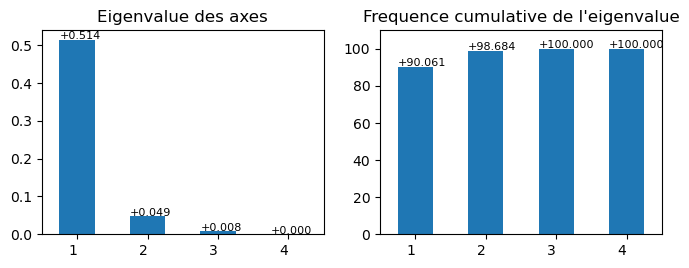

In [36]:
eig = pd.DataFrame(afc.eig_)

r1 = eig.iloc[0]
r2 = eig.iloc[2]
s=list(range(1,len(r1)+1))
r1.index=s
r2.index=s

# https://www.statology.org/pandas-subplots/
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8,3))

### https://stackoverflow.com/questions/25447700/annotate-bars-with-values-on-pandas-bar-plots
aa = r1.plot(kind='bar', ax=axes[0], title='Eigenvalue des axes')
for p in aa.patches:
    b = p.get_bbox()
    # print(b)
    val = "{:+.3f}".format(b.y1 + b.y0)    
    # print(b.x1)    
    aa.annotate(val, (b.x0 , b.y1* 1.005), size=8)
plt.margins(y = 0.1)

bb = r2.plot(kind='bar', ax=axes[1], title="Frequence cumulative de l'eigenvalue")

for container in bb.containers:
    for p in bb.patches:
        b = p.get_bbox()
        # print(b)
        val = "{:+.3f}".format(b.y1 + b.y0)    
        # print(b.x1)    
        bb.annotate(val, (b.x0, b.y1* 1.005), size=8)


plt.margins(y = 0.1)
# Met les valeurs xticks en vertical
fig.autofmt_xdate(rotation=0)
plt.show()

### Distances des lignes / des colonnes

In [37]:
# Calcul des profils des lignes
prof_lig = np.apply_along_axis(arr=D.values,axis=1,
                               func1d=lambda x:x/np.sum(x))
# Calul du profil marginal correspondant
# Cf. ligne grisée de Figure 100, Rakotomalala, 2020
tot_col = ddf.loc['Total'][:5]
prof_marg_lig = tot_col/np.sum(tot_col)

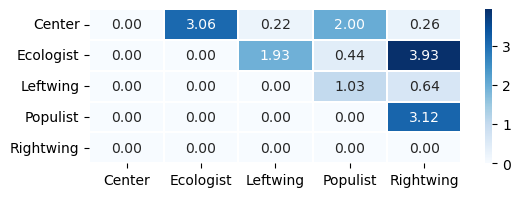

In [38]:
### Distance entre paires de modalités lignes,
# calculée sur la base des valeurs dans la note précédente

fig, ax = plt.subplots(figsize=(6,2))

distPairesLig = np.zeros(shape=(prof_lig.shape[0],prof_lig.shape[0]))
#double boucle
for i in range(prof_lig.shape[0]):
    for j in range(i+1,prof_lig.shape[0]):
        distPairesLig[i,j] = np.sum((prof_lig[i,:]-prof_lig[j,:])**2/prof_marg_lig)

sns.heatmap(distPairesLig,vmin=0,vmax=np.max(distPairesLig),linewidth=0.1,cmap=
'Blues',xticklabels=D.index,yticklabels=D.index,
fmt=".2f", annot=True)


### ATTENTION: plus la couleur est foncée, plus la distance est grande
plt.show()

In [39]:
# Profil marginal des filières (colonnes)
tot_lig = np.sum(D.values,axis=1)
prof_marg_col = tot_lig/np.sum(tot_lig)

# Tableau des profils colonnes
prof_col = np.apply_along_axis(arr=D.values,axis=0,
                               func1d=lambda x:x/np.sum(x))
#print(pd.DataFrame(prof_col,index=D.index,columns=D.columns))
### Transposer pour garder la structure du code Python des lignes 
t_prof_col = prof_col.T

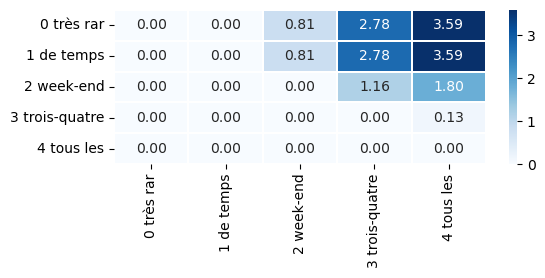

In [40]:
### Distance entre paires de modalités colonnes,
# calculée sur la base des valeurs précédentes  

fig, ax = plt.subplots(figsize=(6,2))


distPairesCol = np.zeros(shape=(t_prof_col.shape[0],
                                t_prof_col.shape[0]))
#double boucle
for i in range(t_prof_col.shape[0]-1):
    for j in range(i+1,t_prof_col.shape[0]):        
        distPairesCol[i,j] = np.sum((t_prof_col[i,:]-t_prof_col[j,:])**2/prof_marg_col)
#distPairesLig[j,i] = distPairesLig[i,j]
#affichage
#print(pd.DataFrame(distPairesLig,index=D.index,columns=D.index))

sns.heatmap(distPairesCol,vmin=0,vmax=np.max(distPairesCol),
            linewidth=0.1,cmap='Blues',xticklabels=D.columns,
            yticklabels=D.columns, 
fmt=".2f", annot=True)

plt.show()

### Graphiques et interprétation du premier plan factoriel

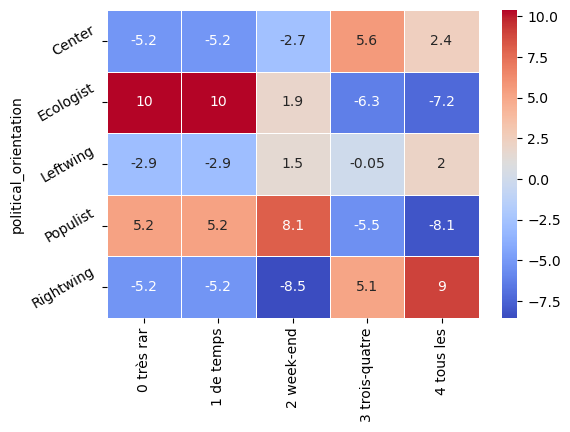

In [41]:
### Résidus pondérés (avec le signe)
### Doc. :
#   Rakotomalala, p.240
residus_ponderes = (round((D.values-dfe)/np.sqrt(dfe),2))
residus_ponderes.columns= D.columns
residus_ponderes.index=D.index


fig, ax = plt.subplots(figsize=(6,4))         
# Sample figsize in inches
g = sns.heatmap(residus_ponderes, annot=residus_ponderes, cmap="coolwarm", linewidths=.5, ax=ax)
labels = residus_ponderes.index
p = g.set_yticklabels(labels, rotation=30)

plt.show()


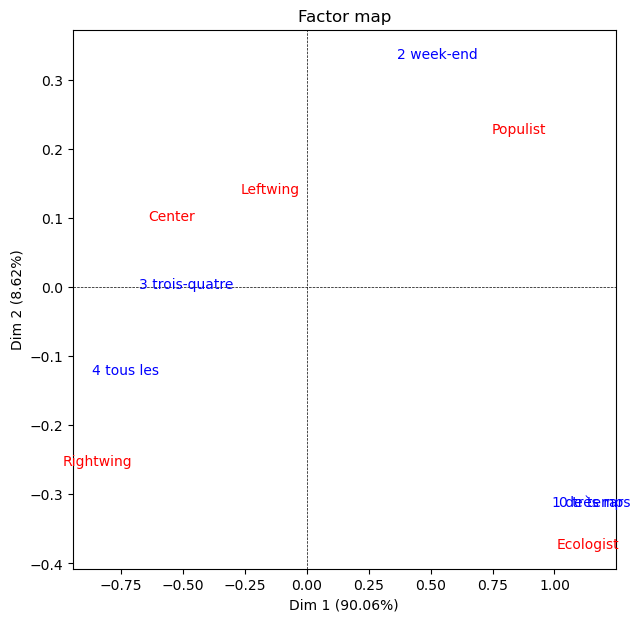

In [42]:
# Représentation simultanée, avec amplification
afc.mapping(num_x_axis=1,num_y_axis=2,figsize=(7,7))

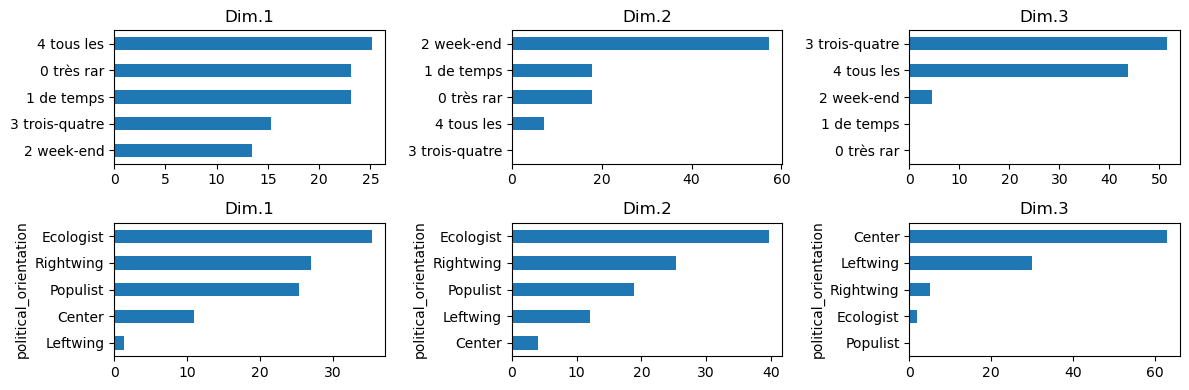

In [43]:
# Informations sur les contributions des colonnes
df = afc.col_topandas()[['col_contrib_dim1',
                         'col_contrib_dim2',
                         'col_contrib_dim3']]

r1 = df.iloc[:,0]
r2 = df.iloc[:,1]
r3 = df.iloc[:,2]

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12,4))

r1.sort_values().plot(kind='barh', ax=axes[0,0], title='Dim.1')
r2.sort_values().plot(kind='barh', ax=axes[0,1], title='Dim.2')
r3.sort_values().plot(kind='barh', ax=axes[0,2], title='Dim.3')

### Rows
df = afc.row_topandas()[['row_contrib_dim1',
                         'row_contrib_dim2',
                         'row_contrib_dim3']]
r1 = df.iloc[:,0]
r2 = df.iloc[:,1]
r3 = df.iloc[:,2]

r1.sort_values().plot(kind='barh', ax=axes[1,0], title='Dim.1')
r2.sort_values().plot(kind='barh', ax=axes[1,1], title='Dim.2')
r3.sort_values().plot(kind='barh', ax=axes[1,2], title='Dim.3')

plt.tight_layout()
plt.show()


## Classe de revenu et orientation politique

In [44]:
c_obs.head(2)

,age,gender,monthly_revenue,newspaper_reading_frequency,political_orientation,time_social_media,generation,classe_revenu,classe_media
id,,,,,,,,,
1,39,Other,18539,daily,Rightwing,54,36-45,12000-299999,37-91
2,81,Male,4261,week-end,Populist,1,66-90,3000-4499,0-4


In [45]:
X = "political_orientation"  # "0"
Y = "classe_revenu"

ddf = c_obs[[Y,X]].pivot_table(index=X,columns=Y,aggfunc=len,margins=True,margins_name="Total").fillna(0).astype(int) 
ddf

classe_revenu,0-2999,10000-11999,12000-299999,3000-4499,4500-5999,6000-7999,8000-9999,Total
political_orientation,,,,,,,,
Center,0,45,155,0,5,38,53,296
Ecologist,93,0,0,62,50,36,2,243
Leftwing,34,85,43,77,80,120,85,524
Populist,70,0,0,114,69,68,13,334
Rightwing,0,17,285,0,0,0,1,303
Total,197,147,483,253,204,262,154,1700


In [46]:
ddf = ddf[['0-2999', '3000-4499', '4500-5999', '6000-7999', '8000-9999', '10000-11999', '12000-299999','Total']]
ddf

classe_revenu,0-2999,3000-4499,4500-5999,6000-7999,8000-9999,10000-11999,12000-299999,Total
political_orientation,,,,,,,,
Center,0,0,5,38,53,45,155,296
Ecologist,93,62,50,36,2,0,0,243
Leftwing,34,77,80,120,85,85,43,524
Populist,70,114,69,68,13,0,0,334
Rightwing,0,0,0,0,1,17,285,303
Total,197,253,204,262,154,147,483,1700


In [47]:
D = ddf.iloc[:-1,:-1].copy(deep=True)
D

classe_revenu,0-2999,3000-4499,4500-5999,6000-7999,8000-9999,10000-11999,12000-299999
political_orientation,,,,,,,
Center,0,0,5,38,53,45,155
Ecologist,93,62,50,36,2,0,0
Leftwing,34,77,80,120,85,85,43
Populist,70,114,69,68,13,0,0
Rightwing,0,0,0,0,1,17,285


In [48]:
## Nombre de modalités ligne, 
# variable: catégories socio-professionnelles des parents
K = D.shape[0]
## Nombre de modalités colonnes,
# variable : filière d'études chosie
L = D.shape[1]
# Effectif total
n = np.sum(D.values)
# Nombre max. de facteur
Hmax = np.min([K-1,L-1])

print('Dimensions: (', K, ',', L, '), effectif:', n, ', nombre max. facteurs:', Hmax)

Dimensions: ( 5 , 7 ), effectif: 1700 , nombre max. facteurs: 4


In [49]:
### Valeurs produites par une fonction
statistic, p, dof, expected = stats.chi2_contingency(D)

print('Chi2 :', statistic, ', dof :',dof)
print('p-value :', p)


print('phi2 = inertie (variance totale) :', statistic/n)


### Tableau à l'indépendance
dfe = round(pd.DataFrame(expected),4)

### Coéfficient de Cramer
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.contingency.association.html

vc = stats.contingency.association(D.iloc[:-1,:-1], method='cramer')
print('Cramer: ', vc)

Chi2 : 1591.9424247189327 , dof : 24
p-value : 0.0
phi2 = inertie (variance totale) : 0.9364367204229016
Cramer:  0.3665847701695317


In [50]:
afc = CA(row_labels=D.index,col_labels=D.columns)
afc.fit(D.values)

CA(col_labels=Index(['0-2999', '3000-4499', '4500-5999', '6000-7999', '8000-9999',
       '10000-11999', '12000-299999'],
      dtype='object', name='classe_revenu'),
   row_labels=Index(['Center', 'Ecologist', 'Leftwing', 'Populist', 'Rightwing'], dtype='object', name='political_orientation'))

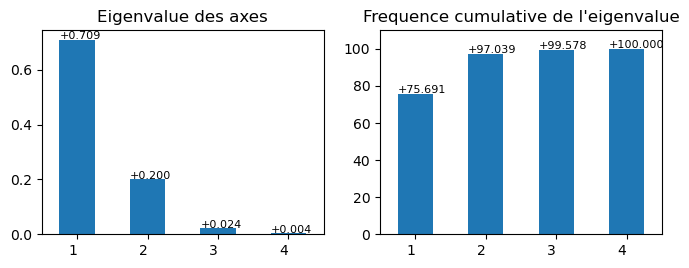

In [51]:
eig = pd.DataFrame(afc.eig_)

r1 = eig.iloc[0]
r2 = eig.iloc[2]
s=list(range(1,len(r1)+1))
r1.index=s
r2.index=s

# https://www.statology.org/pandas-subplots/
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8,3))

### https://stackoverflow.com/questions/25447700/annotate-bars-with-values-on-pandas-bar-plots
aa = r1.plot(kind='bar', ax=axes[0], title='Eigenvalue des axes')
for p in aa.patches:
    b = p.get_bbox()
    # print(b)
    val = "{:+.3f}".format(b.y1 + b.y0)    
    # print(b.x1)    
    aa.annotate(val, (b.x0 , b.y1* 1.005), size=8)
plt.margins(y = 0.1)

bb = r2.plot(kind='bar', ax=axes[1], title="Frequence cumulative de l'eigenvalue")

for container in bb.containers:
    for p in bb.patches:
        b = p.get_bbox()
        # print(b)
        val = "{:+.3f}".format(b.y1 + b.y0)    
        # print(b.x1)    
        bb.annotate(val, (b.x0, b.y1* 1.005), size=8)


plt.margins(y = 0.1)
# Met les valeurs xticks en vertical
fig.autofmt_xdate(rotation=0)
plt.show()

### Graphiques et interprétation du premier plan factoriel

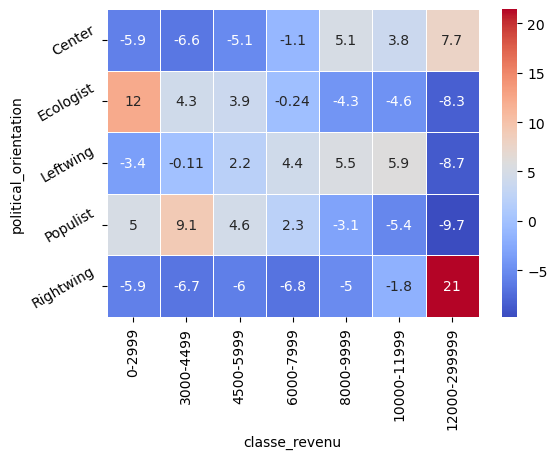

In [52]:
### Résidus pondérés (avec le signe)
### Doc. :
#   Rakotomalala, p.240
residus_ponderes = (round((D.values-dfe)/np.sqrt(dfe),2))
residus_ponderes.columns= D.columns
residus_ponderes.index=D.index


fig, ax = plt.subplots(figsize=(6,4))         
# Sample figsize in inches
g = sns.heatmap(residus_ponderes, annot=residus_ponderes, cmap="coolwarm", linewidths=.5, ax=ax)
labels = residus_ponderes.index
p = g.set_yticklabels(labels, rotation=30)

plt.show()


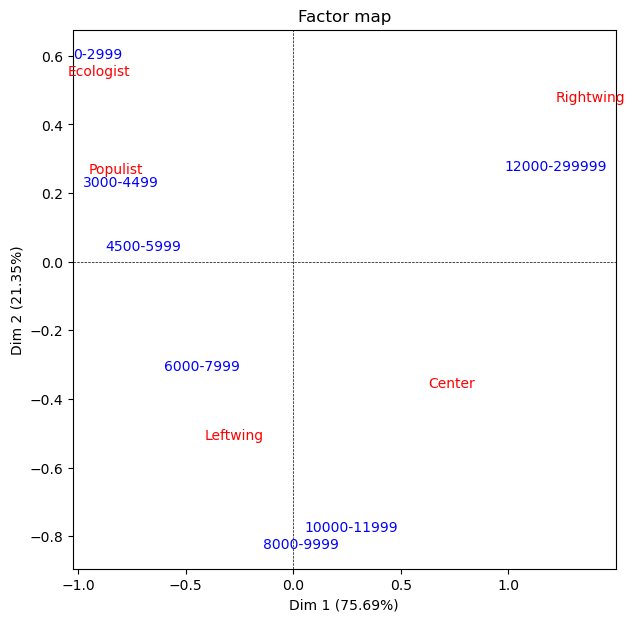

In [53]:
# Représentation simultanée, avec amplification
afc.mapping(num_x_axis=1,num_y_axis=2,figsize=(7,7))

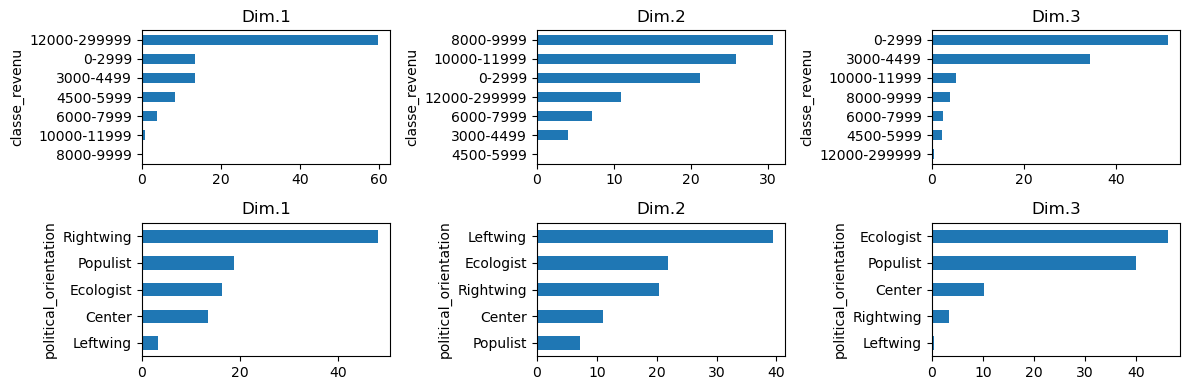

In [54]:
# Informations sur les contributions des colonnes
df = afc.col_topandas()[['col_contrib_dim1',
                         'col_contrib_dim2',
                         'col_contrib_dim3']]

r1 = df.iloc[:,0]
r2 = df.iloc[:,1]
r3 = df.iloc[:,2]

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12,4))

r1.sort_values().plot(kind='barh', ax=axes[0,0], title='Dim.1')
r2.sort_values().plot(kind='barh', ax=axes[0,1], title='Dim.2')
r3.sort_values().plot(kind='barh', ax=axes[0,2], title='Dim.3')

### Rows
df = afc.row_topandas()[['row_contrib_dim1',
                         'row_contrib_dim2',
                         'row_contrib_dim3']]
r1 = df.iloc[:,0]
r2 = df.iloc[:,1]
r3 = df.iloc[:,2]

r1.sort_values().plot(kind='barh', ax=axes[1,0], title='Dim.1')
r2.sort_values().plot(kind='barh', ax=axes[1,1], title='Dim.2')
r3.sort_values().plot(kind='barh', ax=axes[1,2], title='Dim.3')

plt.tight_layout()
plt.show()


## Classe de revenu et de participation aux réseaux sociaux digitaus

In [55]:
c_obs.head(2)

,age,gender,monthly_revenue,newspaper_reading_frequency,political_orientation,time_social_media,generation,classe_revenu,classe_media
id,,,,,,,,,
1,39,Other,18539,daily,Rightwing,54,36-45,12000-299999,37-91
2,81,Male,4261,week-end,Populist,1,66-90,3000-4499,0-4


In [56]:
X = "classe_media"  # "0"
Y = "classe_revenu"

ddf = c_obs[[Y,X]].pivot_table(index=X,columns=Y,aggfunc=len,margins=True,margins_name="Total").fillna(0).astype(int) 
ddf

classe_revenu,0-2999,10000-11999,12000-299999,3000-4499,4500-5999,6000-7999,8000-9999,Total
classe_media,,,,,,,,
0-4,2,5,85,26,19,17,16,170
105-113,15,24,33,19,25,34,16,166
114-122,14,14,44,29,20,36,16,173
123-132,21,22,44,24,26,32,10,179
133-145,20,14,43,26,15,35,15,168
146-162,34,12,37,23,22,24,13,165
163-250,65,9,26,31,11,9,11,162
37-91,9,17,48,28,27,26,21,176
5-36,6,4,74,28,22,24,12,170


In [57]:
ddf = ddf[['0-2999', '3000-4499', '4500-5999', '6000-7999', '8000-9999', '10000-11999', '12000-299999','Total']]
ddf

classe_revenu,0-2999,3000-4499,4500-5999,6000-7999,8000-9999,10000-11999,12000-299999,Total
classe_media,,,,,,,,
0-4,2,26,19,17,16,5,85,170
105-113,15,19,25,34,16,24,33,166
114-122,14,29,20,36,16,14,44,173
123-132,21,24,26,32,10,22,44,179
133-145,20,26,15,35,15,14,43,168
146-162,34,23,22,24,13,12,37,165
163-250,65,31,11,9,11,9,26,162
37-91,9,28,27,26,21,17,48,176
5-36,6,28,22,24,12,4,74,170


In [58]:
D = ddf.iloc[:-1,:-1].copy(deep=True)
D

classe_revenu,0-2999,3000-4499,4500-5999,6000-7999,8000-9999,10000-11999,12000-299999
classe_media,,,,,,,
0-4,2,26,19,17,16,5,85
105-113,15,19,25,34,16,24,33
114-122,14,29,20,36,16,14,44
123-132,21,24,26,32,10,22,44
133-145,20,26,15,35,15,14,43
146-162,34,23,22,24,13,12,37
163-250,65,31,11,9,11,9,26
37-91,9,28,27,26,21,17,48
5-36,6,28,22,24,12,4,74


In [59]:
## Nombre de modalités ligne, 
# variable: catégories socio-professionnelles des parents
K = D.shape[0]
## Nombre de modalités colonnes,
# variable : filière d'études chosie
L = D.shape[1]
# Effectif total
n = np.sum(D.values)
# Nombre max. de facteur
Hmax = np.min([K-1,L-1])

print('Dimensions: (', K, ',', L, '), effectif:', n, ', nombre max. facteurs:', Hmax)

Dimensions: ( 10 , 7 ), effectif: 1700 , nombre max. facteurs: 6


In [60]:
### Valeurs produites par une fonction
statistic, p, dof, expected = stats.chi2_contingency(D)

print('Chi2 :', statistic, ', dof :',dof)
print('p-value :', p)


print('phi2 = inertie (variance totale) :', statistic/n)


### Tableau à l'indépendance
dfe = round(pd.DataFrame(expected),4)

### Coéfficient de Cramer
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.contingency.association.html

vc = stats.contingency.association(D.iloc[:-1,:-1], method='cramer')
print('Cramer: ', vc)

Chi2 : 307.47789015845063 , dof : 54
p-value : 3.652317529939353e-37
phi2 = inertie (variance totale) : 0.1808693471520298
Cramer:  0.18522557456467706


In [61]:
afc = CA(row_labels=D.index,col_labels=D.columns)
afc.fit(D.values)

CA(col_labels=Index(['0-2999', '3000-4499', '4500-5999', '6000-7999', '8000-9999',
       '10000-11999', '12000-299999'],
      dtype='object', name='classe_revenu'),
   row_labels=Index(['0-4', '105-113', '114-122', '123-132', '133-145', '146-162', '163-250',
       '37-91', '5-36', '92-104'],
      dtype='object', name='classe_media'))

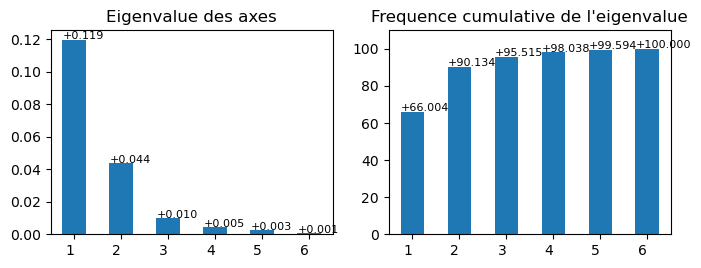

In [62]:
eig = pd.DataFrame(afc.eig_)

r1 = eig.iloc[0]
r2 = eig.iloc[2]
s=list(range(1,len(r1)+1))
r1.index=s
r2.index=s

# https://www.statology.org/pandas-subplots/
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8,3))

### https://stackoverflow.com/questions/25447700/annotate-bars-with-values-on-pandas-bar-plots
aa = r1.plot(kind='bar', ax=axes[0], title='Eigenvalue des axes')
for p in aa.patches:
    b = p.get_bbox()
    # print(b)
    val = "{:+.3f}".format(b.y1 + b.y0)    
    # print(b.x1)    
    aa.annotate(val, (b.x0 , b.y1* 1.005), size=8)
plt.margins(y = 0.1)

bb = r2.plot(kind='bar', ax=axes[1], title="Frequence cumulative de l'eigenvalue")

for container in bb.containers:
    for p in bb.patches:
        b = p.get_bbox()
        # print(b)
        val = "{:+.3f}".format(b.y1 + b.y0)    
        # print(b.x1)    
        bb.annotate(val, (b.x0, b.y1* 1.005), size=8)


plt.margins(y = 0.1)
# Met les valeurs xticks en vertical
fig.autofmt_xdate(rotation=0)
plt.show()

### Graphiques et interprétation du premier plan factoriel

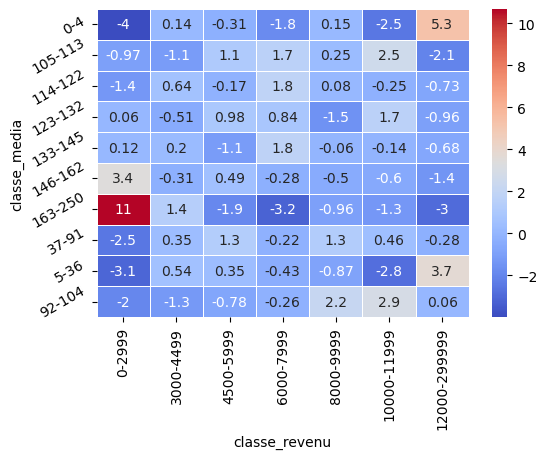

In [63]:
### Résidus pondérés (avec le signe)
### Doc. :
#   Rakotomalala, p.240
residus_ponderes = (round((D.values-dfe)/np.sqrt(dfe),2))
residus_ponderes.columns= D.columns
residus_ponderes.index=D.index


fig, ax = plt.subplots(figsize=(6,4))         
# Sample figsize in inches
g = sns.heatmap(residus_ponderes, annot=residus_ponderes, cmap="coolwarm", linewidths=.5, ax=ax)
labels = residus_ponderes.index
p = g.set_yticklabels(labels, rotation=30)

plt.show()


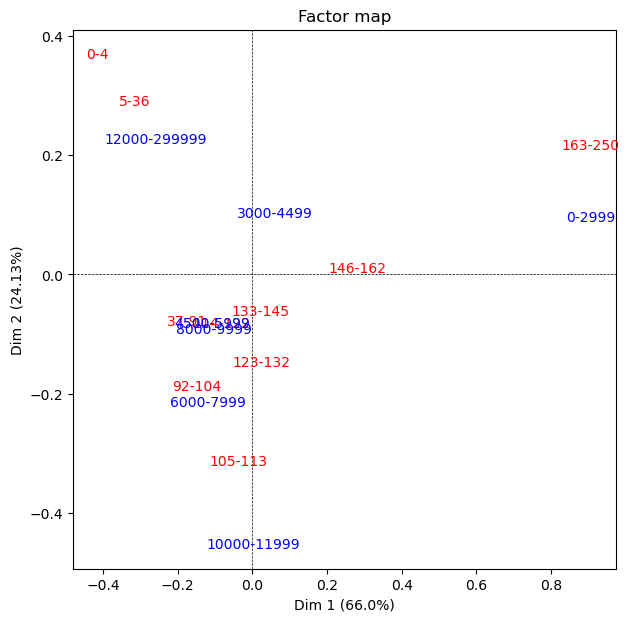

In [64]:
# Représentation simultanée, avec amplification
afc.mapping(num_x_axis=1,num_y_axis=2,figsize=(7,7))

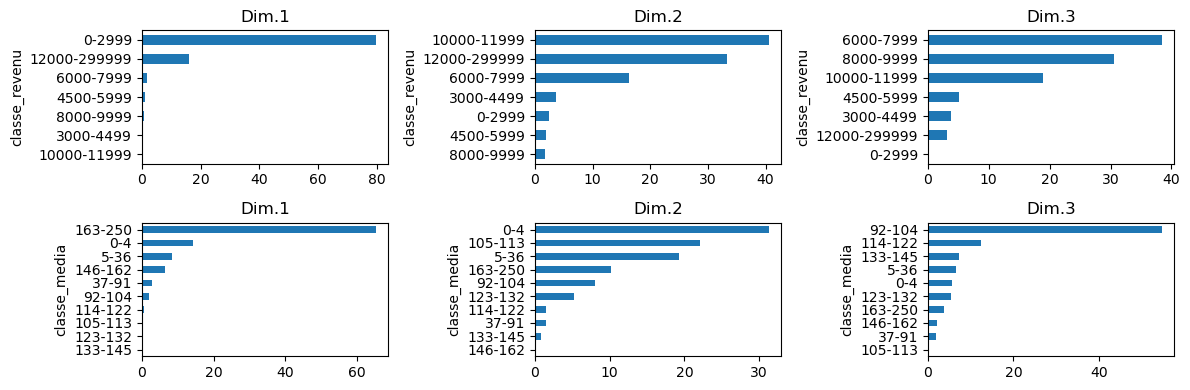

In [65]:
# Informations sur les contributions des colonnes
df = afc.col_topandas()[['col_contrib_dim1',
                         'col_contrib_dim2',
                         'col_contrib_dim3']]

r1 = df.iloc[:,0]
r2 = df.iloc[:,1]
r3 = df.iloc[:,2]

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12,4))

r1.sort_values().plot(kind='barh', ax=axes[0,0], title='Dim.1')
r2.sort_values().plot(kind='barh', ax=axes[0,1], title='Dim.2')
r3.sort_values().plot(kind='barh', ax=axes[0,2], title='Dim.3')

### Rows
df = afc.row_topandas()[['row_contrib_dim1',
                         'row_contrib_dim2',
                         'row_contrib_dim3']]
r1 = df.iloc[:,0]
r2 = df.iloc[:,1]
r3 = df.iloc[:,2]

r1.sort_values().plot(kind='barh', ax=axes[1,0], title='Dim.1')
r2.sort_values().plot(kind='barh', ax=axes[1,1], title='Dim.2')
r3.sort_values().plot(kind='barh', ax=axes[1,2], title='Dim.3')

plt.tight_layout()
plt.show()
